**Chapter 2 – End-to-End Machine Learning Project**

*This notebook contains all the sample code and solutions to the exercises in chapter 2.*

<table align="left">
  <td>
    <a href="https://colab.research.google.com/github/ageron/handson-mlp/blob/main/02_end_to_end_machine_learning_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
  </td>
  <td>
    <a target="_blank" href="https://kaggle.com/kernels/welcome?src=https://github.com/ageron/handson-mlp/blob/main/02_end_to_end_machine_learning_project.ipynb"><img src="https://kaggle.com/static/images/open-in-kaggle.svg" /></a>
  </td>
</table>

In [1]:
print("Welcome to Machine Learning!")

Welcome to Machine Learning!


This project requires Python 3.10 or above:

In [2]:
import sys

assert sys.version_info >= (3, 10)

It also requires Scikit-Learn ≥ 1.6.1:

In [3]:
from packaging.version import Version
import sklearn

assert Version(sklearn.__version__) >= Version("1.6.1")

# Get the Data

*Welcome to Machine Learning Housing Corp.! Your task is to predict median house values in Californian districts, given a number of features from these districts.*

## Download the Data

In [4]:
from pathlib import Path
import polars as pl
import tarfile
import urllib.request


def load_housing_data():
    tarball_path = Path("datasets/housing.tgz")
    if not tarball_path.is_file():
        Path("datasets").mkdir(parents=True, exist_ok=True)
        url = "https://github.com/ageron/data/raw/main/housing.tgz"
        urllib.request.urlretrieve(url, tarball_path)
        with tarfile.open(tarball_path) as housing_tarball:
            housing_tarball.extractall(path="datasets", filter="data")
    return pl.read_csv(Path("datasets/housing/housing.csv"))


housing_full = load_housing_data()

## Take a Quick Look at the Data Structure

In [5]:
housing_full.head()

longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
f64,f64,f64,f64,f64,f64,f64,f64,f64,str
-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,"""NEAR BAY"""
-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,"""NEAR BAY"""
-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,"""NEAR BAY"""
-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,"""NEAR BAY"""
-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,"""NEAR BAY"""


In [6]:
housing_full.describe()

statistic,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,str
"""count""",20640.0,20640.0,20640.0,20640.0,20433.0,20640.0,20640.0,20640.0,20640.0,"""20640"""
"""null_count""",0.0,0.0,0.0,0.0,207.0,0.0,0.0,0.0,0.0,"""0"""
"""mean""",-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.53968,3.870671,206855.816909,null
"""std""",2.003532,2.135952,12.585558,2181.615252,421.38507,1132.462122,382.329753,1.899822,115395.615874,null
"""min""",-124.35,32.54,1.0,2.0,1.0,3.0,1.0,0.4999,14999.0,"""<1H OCEAN"""
"""25%""",-121.8,33.93,18.0,1448.0,296.0,787.0,280.0,2.5637,119600.0,null
"""50%""",-118.49,34.26,29.0,2127.0,435.0,1166.0,409.0,3.5349,179700.0,null
"""75%""",-118.01,37.71,37.0,3148.0,647.0,1725.0,605.0,4.7431,264700.0,null
"""max""",-114.31,41.95,52.0,39320.0,6445.0,35682.0,6082.0,15.0001,500001.0,"""NEAR OCEAN"""


In [7]:
housing_full["ocean_proximity"].value_counts(sort=True)

ocean_proximity,count
str,u32
"""<1H OCEAN""",9136
"""INLAND""",6551
"""NEAR OCEAN""",2658
"""NEAR BAY""",2290
"""ISLAND""",5


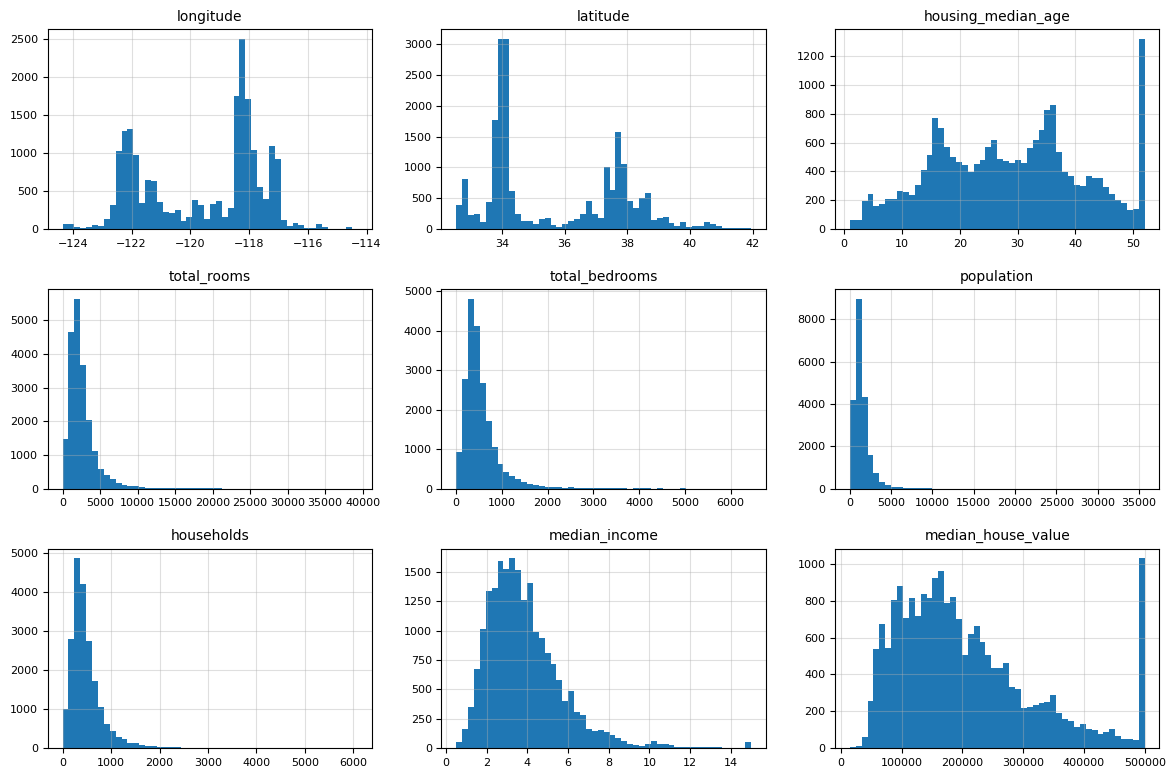

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# extra code – the next 5 lines define the default font sizes
plt.rc("font", size=14)
plt.rc("axes", labelsize=14, titlesize=14)
plt.rc("legend", fontsize=14)
plt.rc("xtick", labelsize=10)
plt.rc("ytick", labelsize=10)


fig, axes = plt.subplots(3, 3, figsize=(12, 8))
for ax, col in zip(axes.flat, housing_full.columns):
    ax.grid(alpha=0.4)
    ax.hist(housing_full[col].drop_nulls(), bins=50)
    ax.set_title(col, fontsize=10)
    ax.tick_params(labelsize=8)

# Hide any extra subplots
for ax in axes.flat[len(housing_full.columns) :]:
    ax.set_visible(False)

plt.tight_layout()

plt.show()

## Create a Test Set

In [9]:
import numpy as np


def shuffle_and_split_data(data, test_ratio, rng):
    shuffled_indices = rng.permutation(len(data))
    test_set_size = int(len(data) * test_ratio)
    test_indices = shuffled_indices[:test_set_size]
    train_indices = shuffled_indices[test_set_size:]
    return data[train_indices], data[test_indices]

To ensure that this notebook's outputs remain the same every time we run it, we need to set the random seed:

In [10]:
rng = np.random.default_rng(seed=42)
train_set, test_set = shuffle_and_split_data(housing_full, 0.2, rng)
len(train_set)

16512

In [11]:
len(test_set)

4128

Sadly, this won't guarantee that this notebook will output exactly the same results as in the book, since there are other possible sources of variation. The most important is the fact that algorithms get tweaked over time when libraries evolve. So please tolerate some minor differences: hopefully, most of the outputs should be the same, or at least in the right ballpark.

Note: another source of randomness is the order of Python sets: it is based on Python's `hash()` function, which is randomly "salted" when Python starts up (this started in Python 3.3, to prevent some denial-of-service attacks). To remove this randomness, the solution is to set the `PYTHONHASHSEED` environment variable to `"0"` _before_ Python even starts up. Nothing will happen if you do it after that. Luckily, if you're running this notebook on Colab, the variable is already set for you.

**Polars note:** The code below uses Polars' native `.hash()` method for deterministic train-test splitting. This is much faster than the book's `crc32` approach since it runs in Rust instead of Python. The hash values will differ from the book's outputs, but the splitting behavior is equally valid and deterministic.

In [12]:
def split_data_with_id_hash(data, test_ratio, id_column):
    # Use Polars native hash() method instead of map_elements with crc32
    # This is much faster as it runs in Rust instead of Python
    in_test_set = data.select(
        (pl.col(id_column).hash() < (test_ratio * 2**64)).alias("in_test_set")
    )["in_test_set"]
    return data.filter(~in_test_set), data.filter(in_test_set)

In [13]:
housing_with_id = housing_full.with_row_index("index")  # adds an `index` column
train_set, test_set = split_data_with_id_hash(housing_with_id, 0.2, "index")

In [14]:
housing_with_id = housing_with_id.with_columns(
    (pl.col("longitude") * 1000 + pl.col("latitude")).alias("id")
)
train_set, test_set = split_data_with_id_hash(housing_with_id, 0.2, "id")

In [15]:
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(housing_full, test_size=0.2, random_state=42)

In [16]:
test_set["total_bedrooms"].null_count()

44

To find the probability that a random sample of 1,000 people contains less than 49% female or more than 54% female when the population's female ratio is 51.6%, we use the [binomial distribution](https://en.wikipedia.org/wiki/Binomial_distribution). The `cdf()` method of the binomial distribution gives us the probability that the number of females will be equal or less than the given value.

In [17]:
# extra code – shows how to compute the 10.7% proba of getting a bad sample

from scipy.stats import binom

sample_size = 1000
ratio_female = 0.516
proba_too_small = binom(sample_size, ratio_female).cdf(490 - 1)
proba_too_large = 1 - binom(sample_size, ratio_female).cdf(540)
print(proba_too_small + proba_too_large)

0.10727422667455991


If you prefer simulations over maths, here's how you could get roughly the same result:

***

### Why do this simulation?

| Approach | Pros | Cons |
| :--- | :--- | :--- |
| **Binomial CDF** (previous code) | Exact, fast, mathematical | Requires knowing the right distribution |
| **Monte Carlo** (this code) | Intuitive, visualizable, works for complex scenarios | Approximate, slower |

This simulation demonstrates that theoretical probability matches empirical reality — a powerful way to build intuition about sampling distributions.

In [18]:
# extra code – shows another way to estimate the probability of bad sample

rng = np.random.default_rng(seed=42)
samples = (rng.random((100_000, sample_size)) < ratio_female).sum(axis=1)
((samples < 490) | (samples > 540)).mean()

np.float64(0.1077)

In [19]:
housing_full = housing_full.with_columns(
    pl.col("median_income")
    .cut([1.5, 3.0, 4.5, 6.0], labels=["1", "2", "3", "4", "5"])
    .alias("income_cat")
)

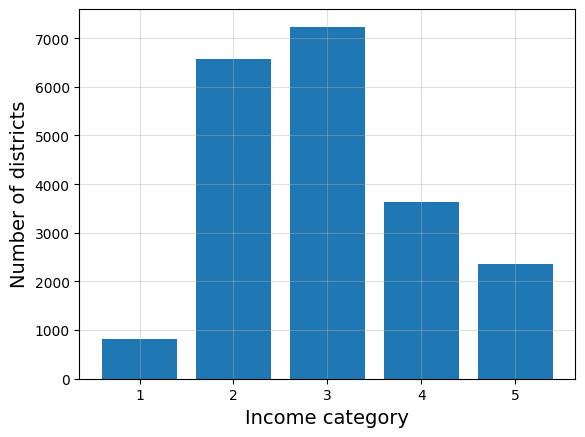

In [20]:
cat_counts = housing_full["income_cat"].value_counts().sort("income_cat")
plt.bar(cat_counts["income_cat"].cast(pl.String), cat_counts["count"])
plt.grid(alpha=0.4)
plt.xlabel("Income category")
plt.ylabel("Number of districts")

plt.show()

In [21]:
from sklearn.model_selection import StratifiedShuffleSplit

splitter = StratifiedShuffleSplit(n_splits=10, test_size=0.2, random_state=42)
strat_splits = []
for train_index, test_index in splitter.split(housing_full, housing_full["income_cat"]):
    strat_train_set = housing_full[train_index]
    strat_test_set = housing_full[test_index]
    strat_splits.append([strat_train_set, strat_test_set])

In [22]:
strat_train_set, strat_test_set = strat_splits[0]

It's much shorter to get a single stratified split:

In [23]:
strat_train_set, strat_test_set = train_test_split(
    housing_full, test_size=0.2, stratify=housing_full["income_cat"], random_state=42
)

In [24]:
strat_test_set["income_cat"].value_counts().sort("income_cat").with_columns(
    (pl.col("count") / len(strat_test_set)).alias("proportion")
)

income_cat,count,proportion
cat,u32,f64
"""1""",165,0.039971
"""2""",1316,0.318798
"""3""",1447,0.350533
"""4""",728,0.176357
"""5""",472,0.114341


In [25]:
# extra code – computes the data for Figure 2–10


def income_cat_proportions(data):
    vc = data["income_cat"].value_counts().sort("income_cat")
    return vc.with_columns((pl.col("count") / len(data)).alias("proportion"))


from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(housing_full, test_size=0.2, random_state=42)

overall = income_cat_proportions(housing_full)
strat = income_cat_proportions(strat_test_set)
random = income_cat_proportions(test_set)

compare_props = pl.DataFrame(
    {
        "Income Category": overall["income_cat"].cast(pl.String),
        "Overall %": overall["proportion"],
        "Stratified %": strat["proportion"],
        "Random %": random["proportion"],
    }
)
compare_props = compare_props.with_columns(
    ((pl.col("Random %") / pl.col("Overall %") - 1) * 100).alias("Rand. error %"),
    ((pl.col("Stratified %") / pl.col("Overall %") - 1) * 100).alias("Strat. error %"),
)

compare_props

Income Category,Overall %,Stratified %,Random %,Rand. error %,Strat. error %
str,f64,f64,f64,f64,f64
"""1""",0.039826,0.039971,0.042393,6.447689,0.364964
"""2""",0.318847,0.318798,0.307413,-3.586081,-0.015195
"""3""",0.350581,0.350533,0.345203,-1.533997,-0.01382
"""4""",0.176308,0.176357,0.184109,4.424292,0.02748
"""5""",0.114438,0.114341,0.120882,5.630821,-0.084674


In [26]:
strat_train_set = strat_train_set.drop("income_cat")
strat_test_set = strat_test_set.drop("income_cat")

# Discover and Visualize the Data to Gain Insights

In [27]:
housing = strat_train_set

## Visualizing Geographical Data

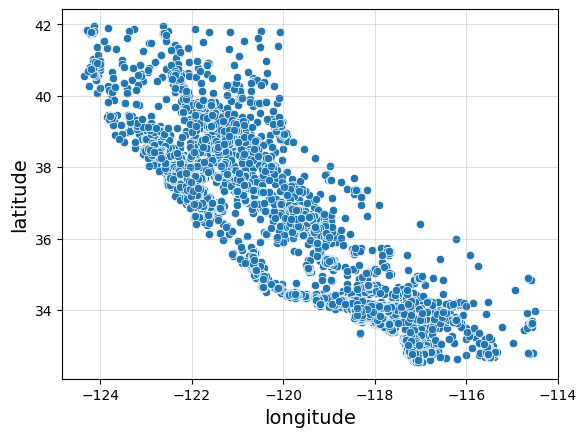

In [28]:
sns.scatterplot(data=housing, x="longitude", y="latitude")
plt.grid(alpha=0.4)
plt.show()

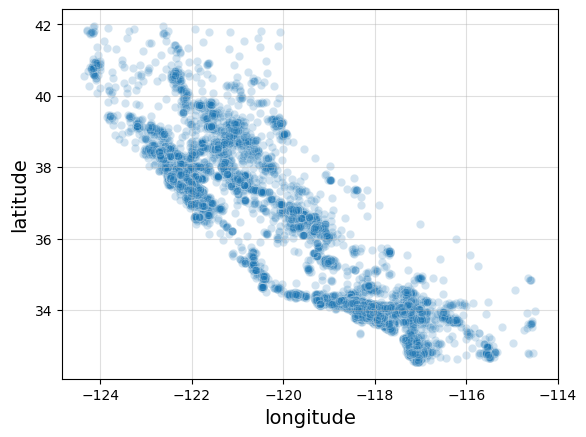

In [29]:
sns.scatterplot(data=housing, x="longitude", y="latitude", alpha=0.2)
plt.grid(alpha=0.4)

plt.show()

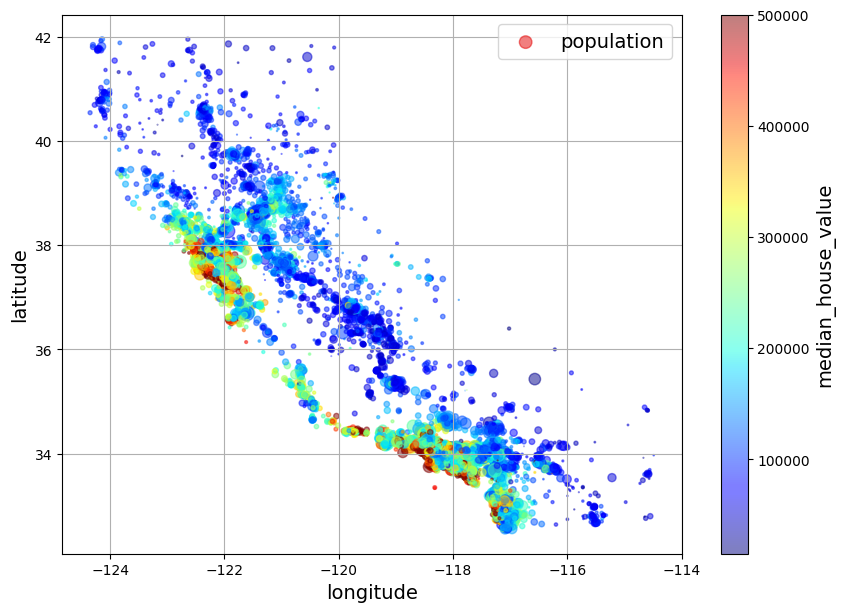

In [30]:
fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(
    housing["longitude"],
    housing["latitude"],
    s=housing["population"] / 100,
    c=housing["median_house_value"],
    cmap="jet",
    alpha=0.5,
)
plt.colorbar(scatter, label="median_house_value")
ax.set_xlabel("longitude")
ax.set_ylabel("latitude")
ax.legend(["population"], loc="upper right")
ax.grid(True)
plt.show()

The next cell generates the first figure in the chapter (this code is not in the book). It's just a beautified version of the previous figure, with an image of California added in the background, nicer label names and no grid.

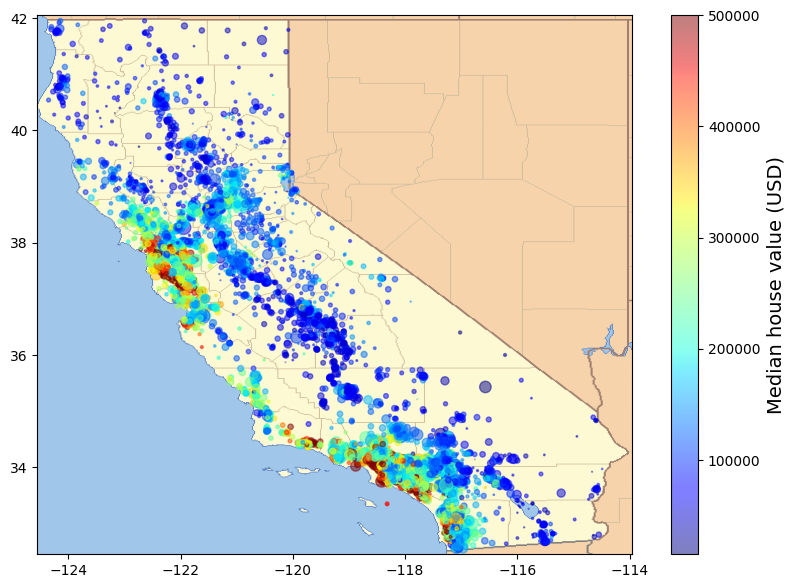

In [31]:
# extra code – this cell generates the first figure in the chapter

# Download the California image
filename = "california.png"
filepath = Path(f"my_{filename}")
if not filepath.is_file():
    homlp_root = "https://github.com/ageron/handson-mlp/raw/main/"
    url = homlp_root + "images/end_to_end_project/" + filename
    print("Downloading", filename)
    urllib.request.urlretrieve(url, filepath)

fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(
    housing["longitude"],
    housing["latitude"],
    s=housing["population"] / 100,
    c=housing["median_house_value"],
    cmap="jet",
    alpha=0.5,
    label="Population",
)
plt.colorbar(scatter, label="Median house value (USD)")

california_img = plt.imread(filepath)
axis = -124.55, -113.95, 32.45, 42.05
plt.axis(axis)
plt.imshow(california_img, extent=axis)

plt.show()

## Looking for Correlations

In [32]:
# Get the full correlation matrix using native Polars method
# Select only numeric columns first, as corr() requires numeric data

import polars.selectors as cs

corr_matrix = housing.select(cs.numeric()).corr()

In [33]:
# Get correlations with median_house_value using native Polars
target = "median_house_value"
num_cols = housing.select(cs.numeric()).columns

corr_with_mhv = pl.DataFrame(
    {
        "feature": num_cols,
        "correlation": [
            housing.select(pl.corr(pl.col(col), pl.col(target))).item()
            for col in num_cols
        ],
    }
).sort("correlation", descending=True)
corr_with_mhv

feature,correlation
str,f64
"""median_house_value""",1.0
"""median_income""",0.68838
"""total_rooms""",0.137455
"""housing_median_age""",0.102175
"""households""",0.071426
"""total_bedrooms""",0.054635
"""population""",-0.020153
"""longitude""",-0.050859
"""latitude""",-0.139584


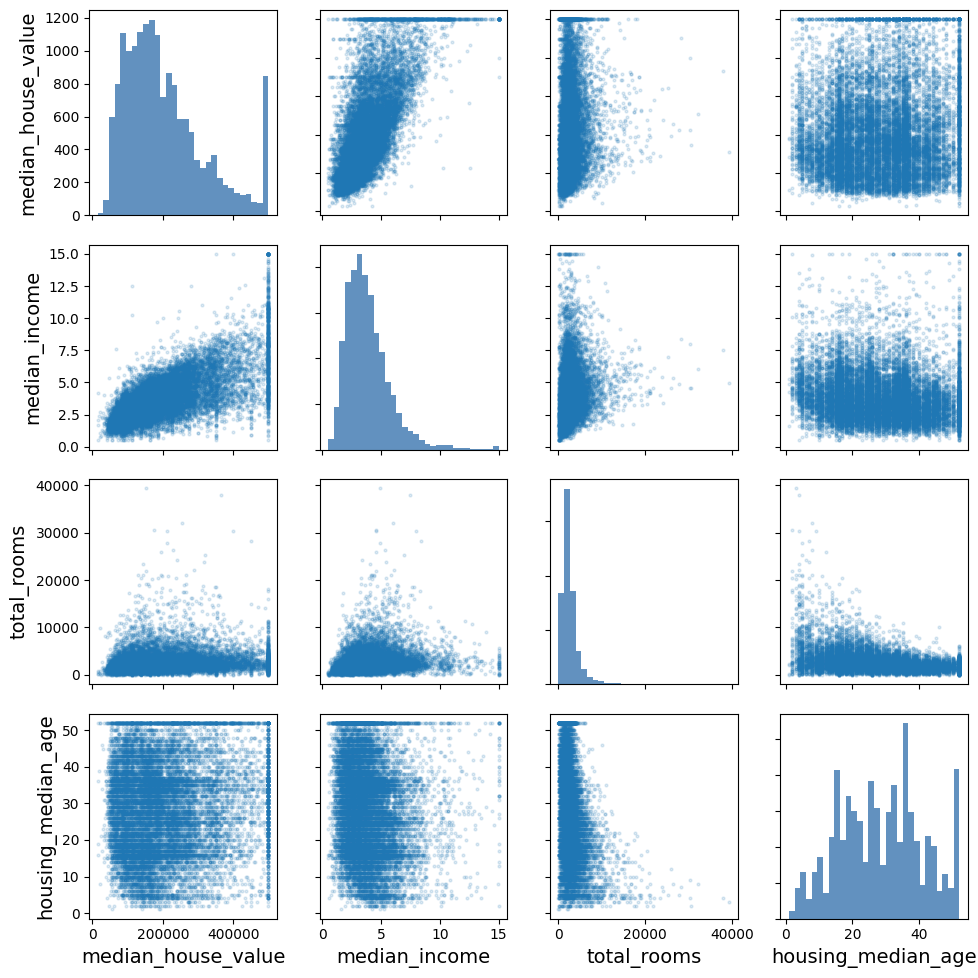

In [34]:
# Seaborn pairplot relies on pandas for this workflow, so use a pure
# matplotlib scatter-matrix style plot directly from Polars columns.
attributes = [
    "median_house_value",
    "median_income",
    "total_rooms",
    "housing_median_age",
]
plot_data = housing.select(attributes)
n = len(attributes)
fig, axes = plt.subplots(n, n, figsize=(10, 10))
for row, y_col in enumerate(attributes):
    y = plot_data[y_col].to_numpy()
    for col, x_col in enumerate(attributes):
        ax = axes[row, col]
        if row == col:
            ax.hist(y, bins=30, color="#3b76af", alpha=0.8)
        else:
            ax.scatter(plot_data[x_col].to_numpy(), y, s=4, alpha=0.15)
        if row == n - 1:
            ax.set_xlabel(x_col)
        else:
            ax.set_xticklabels([])
        if col == 0:
            ax.set_ylabel(y_col)
        else:
            ax.set_yticklabels([])
plt.tight_layout()
plt.show()

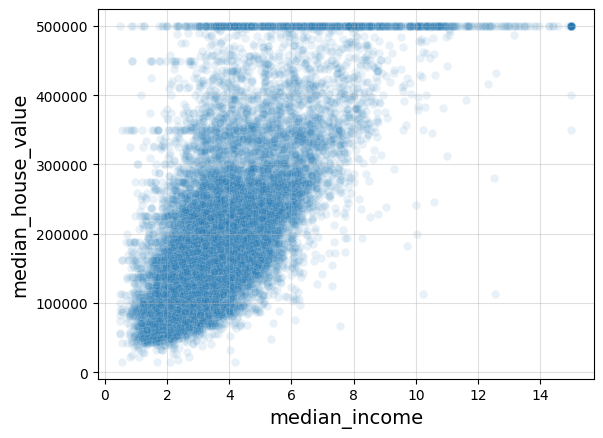

In [35]:
sns.scatterplot(data=housing, x="median_income", y="median_house_value", alpha=0.1)
plt.grid(alpha=0.4)

plt.show()

## Experimenting with Attribute Combinations

In [36]:
housing = housing.with_columns(
    (pl.col("total_rooms") / pl.col("households")).alias("rooms_per_house"),
    (pl.col("total_bedrooms") / pl.col("total_rooms")).alias("bedrooms_ratio"),
    (pl.col("population") / pl.col("households")).alias("people_per_house"),
)

In [37]:
# Get correlations with median_house_value using native Polars
target = "median_house_value"
num_cols = housing.select(cs.numeric()).columns

corr_with_mhv = pl.DataFrame(
    {
        "feature": num_cols,
        "correlation": [
            housing.select(pl.corr(pl.col(col), pl.col(target))).item()
            for col in num_cols
        ],
    }
).sort("correlation", descending=True)

# Print all rows

with pl.Config(tbl_rows=-1, tbl_cols=-1, tbl_width_chars=-1):
    print(corr_with_mhv)

shape: (12, 2)
┌────────────────────┬─────────────┐
│ feature            ┆ correlation │
│ ---                ┆ ---         │
│ str                ┆ f64         │
╞════════════════════╪═════════════╡
│ median_house_value ┆ 1.0         │
│ median_income      ┆ 0.68838     │
│ rooms_per_house    ┆ 0.143663    │
│ total_rooms        ┆ 0.137455    │
│ housing_median_age ┆ 0.102175    │
│ households         ┆ 0.071426    │
│ total_bedrooms     ┆ 0.054635    │
│ population         ┆ -0.020153   │
│ people_per_house   ┆ -0.038224   │
│ longitude          ┆ -0.050859   │
│ latitude           ┆ -0.139584   │
│ bedrooms_ratio     ┆ -0.256397   │
└────────────────────┴─────────────┘


# Prepare the Data for Machine Learning Algorithms

Let's revert to the original training set and separate the target (note that `strat_train_set.drop()` creates a copy of `strat_train_set` without the column, it doesn't actually modify `strat_train_set` itself, as Polars DataFrames are immutable):

In [38]:
housing = strat_train_set.drop("median_house_value")
housing_labels = strat_train_set["median_house_value"]

**Polars note:** The above cell creates new DataFrames without the `median_house_value` column. In Polars, DataFrames are immutable, so `.drop()` returns a new DataFrame without modifying the original `strat_train_set`.

## Data Cleaning

In the book 3 options are listed to handle the NaN values:

```python
housing.drop_nulls(subset=["total_bedrooms"])                    # option 1

housing.drop("total_bedrooms")                                    # option 2

median = housing["total_bedrooms"].median()                       # option 3
housing.with_columns(pl.col("total_bedrooms").fill_null(median))
```

**Polars note:** Polars DataFrames are immutable, so operations like `.drop_nulls()`, `.drop()`, and `.with_columns()` automatically return new DataFrames without modifying the original. No need for explicit `.copy()` or `.clone()` calls like in pandas.

In [39]:
null_rows_mask = pl.any_horizontal(pl.all().is_null())
housing.filter(null_rows_mask).head()

longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
f64,f64,f64,f64,f64,f64,f64,f64,str
-120.67,40.5,15.0,5343.0,null,2503.0,902.0,3.5962,"""INLAND"""
-117.96,34.03,35.0,2093.0,null,1755.0,403.0,3.4115,"""<1H OCEAN"""
-118.05,34.04,33.0,1348.0,null,1098.0,257.0,4.2917,"""<1H OCEAN"""
-118.88,34.17,15.0,4260.0,null,1701.0,669.0,5.1033,"""<1H OCEAN"""
-117.87,33.62,8.0,1266.0,null,375.0,183.0,9.802,"""<1H OCEAN"""


In [40]:
housing_option1 = housing

housing_option1 = housing_option1.drop_nulls(subset=["total_bedrooms"])  # option 1

housing_option1.filter(null_rows_mask).head()

longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
f64,f64,f64,f64,f64,f64,f64,f64,str


In [41]:
housing_option2 = housing

housing_option2 = housing_option2.drop("total_bedrooms")  # option 2

housing_option2.head()

longitude,latitude,housing_median_age,total_rooms,population,households,median_income,ocean_proximity
f64,f64,f64,f64,f64,f64,f64,str
-122.42,37.8,52.0,3321.0,1576.0,1034.0,2.0987,"""NEAR BAY"""
-118.38,34.14,40.0,1965.0,666.0,357.0,6.0876,"""<1H OCEAN"""
-121.98,38.36,33.0,1083.0,562.0,203.0,2.433,"""INLAND"""
-117.11,33.75,17.0,4174.0,1845.0,780.0,2.2618,"""INLAND"""
-118.15,33.77,36.0,4366.0,1912.0,1172.0,3.5292,"""NEAR OCEAN"""


In [42]:
housing_option3 = housing

median = housing["total_bedrooms"].median()
housing_option3 = housing_option3.with_columns(
    pl.col("total_bedrooms").fill_null(median)
)  # option 3

housing_option3.filter(null_rows_mask).head()

longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
f64,f64,f64,f64,f64,f64,f64,f64,str


In [43]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

Separating out the numerical attributes to use the `"median"` strategy (as it cannot be calculated on text attributes like `ocean_proximity`):

In [44]:
housing_num = housing.select(cs.numeric())

In [45]:
imputer.fit(housing_num)

,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feature has nomissing values at fit/train time, the feature won't appear onthe missing indicator even if there are missing values attransform/test time.",False
,"keep_empty_features keep_empty_features: bool, default=FalseIf True, features that consist exclusively of missing values when`fit` is called are returned in results when `transform` is called.The imputed value is always `0` except when `strategy=""constant""`in which case `fill_value` will be used instead... versionadded:: 1.2",False


In [46]:
imputer.statistics_

array([-118.51  ,   34.26  ,   29.    , 2125.    ,  434.    , 1167.    ,
        408.    ,    3.5385])

Check that this is the same as manually computing the median of each attribute:

In [47]:
list(housing_num.median().row(0))

[-118.51, 34.26, 29.0, 2125.0, 434.0, 1167.0, 408.0, 3.5385]

Transform the training set:

In [48]:
X = imputer.transform(housing_num)

In [49]:
imputer.feature_names_in_

array(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income'],
      dtype=object)

In [50]:
imputer.strategy

'median'

In [51]:
housing_tr = pl.DataFrame(X, schema=housing_num.columns)

In [52]:
housing_tr.filter(null_rows_mask).head()

longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
f64,f64,f64,f64,f64,f64,f64,f64


In [53]:
# Alternative approach: use sklearn's native Polars output (scikit-learn >= 1.2)
# If you enable this, transformers will return Polars DataFrames directly (: Polars in, Polars out), so you won't need the manual pl.DataFrame() conversion above:

# from sklearn import set_config
# set_config(transform_output="polars")

Now let's drop some outliers:

In [54]:
from sklearn.ensemble import IsolationForest

isolation_forest = IsolationForest(random_state=42)
outlier_pred = isolation_forest.fit_predict(X)

In [55]:
outlier_pred

array([-1,  1,  1, ...,  1,  1,  1], shape=(16512,))

If you wanted to drop outliers, you would run the following code:

In [56]:
# housing = housing.head(len(housing.filter(pl.Series(outlier_pred == 1))))
# housing_labels = housing_labels.head(len(housing_labels.filter(pl.Series(outlier_pred == 1))))

## Handling Text and Categorical Attributes

Now let's preprocess the categorical input feature, `ocean_proximity`:

In [57]:
housing_cat = housing[["ocean_proximity"]]
housing_cat.head(8)

ocean_proximity
str
"""NEAR BAY"""
"""<1H OCEAN"""
"""INLAND"""
"""INLAND"""
"""NEAR OCEAN"""
"""INLAND"""
"""<1H OCEAN"""
"""NEAR BAY"""


In [58]:
from sklearn.preprocessing import OrdinalEncoder

ordinal_encoder = OrdinalEncoder()
housing_cat_encoded = ordinal_encoder.fit_transform(housing_cat)

In [59]:
housing_cat_encoded[:8]

array([[3.],
       [0.],
       [1.],
       [1.],
       [4.],
       [1.],
       [0.],
       [3.]])

In [60]:
ordinal_encoder.categories_

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

In [61]:
from sklearn.preprocessing import OneHotEncoder

cat_encoder = OneHotEncoder()
housing_cat_1hot = cat_encoder.fit_transform(housing_cat)

In [62]:
housing_cat_1hot

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 16512 stored elements and shape (16512, 5)>

By default, the `OneHotEncoder` class returns a sparse array, but we can convert it to a dense array if needed by calling the `toarray()` method:

In [63]:
housing_cat_1hot.toarray()

array([[0., 0., 0., 1., 0.],
       [1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0.],
       ...,
       [0., 0., 0., 0., 1.],
       [1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1.]], shape=(16512, 5))

Alternatively, you can set `sparse_output=False` when creating the `OneHotEncoder` (note: the `sparse` hyperparameter was renamned to `sparse_output` in Scikit-Learn 1.2):

In [64]:
cat_encoder = OneHotEncoder(sparse_output=False)
housing_cat_1hot = cat_encoder.fit_transform(housing_cat)
housing_cat_1hot

array([[0., 0., 0., 1., 0.],
       [1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0.],
       ...,
       [0., 0., 0., 0., 1.],
       [1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1.]], shape=(16512, 5))

In [65]:
cat_encoder.categories_

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

In [66]:
df_test = pl.DataFrame({"ocean_proximity": ["INLAND", "NEAR BAY"]})
df_test.to_dummies("ocean_proximity")

ocean_proximity_INLAND,ocean_proximity_NEAR BAY
u8,u8
1,0
0,1


In [67]:
cat_encoder.transform(df_test)

array([[0., 1., 0., 0., 0.],
       [0., 0., 0., 1., 0.]])

In [68]:
df_test_unknown = pl.DataFrame({"ocean_proximity": ["<2H OCEAN", "ISLAND"]})
df_test_unknown.to_dummies("ocean_proximity")

ocean_proximity_<2H OCEAN,ocean_proximity_ISLAND
u8,u8
1,0
0,1


In [69]:
cat_encoder.handle_unknown = "ignore"
cat_encoder.transform(df_test_unknown)

array([[0., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0.]])

In [70]:
cat_encoder.feature_names_in_

array(['ocean_proximity'], dtype=object)

In [71]:
cat_encoder.get_feature_names_out()

array(['ocean_proximity_<1H OCEAN', 'ocean_proximity_INLAND',
       'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY',
       'ocean_proximity_NEAR OCEAN'], dtype=object)

In [72]:
# Convert sparse/dense array to Polars DataFrame
# Note: `get_feature_names_out()` returns a numpy array, but Polars' `schema`
# parameter requires a Python list, so we wrap it with `list()`
df_output = pl.DataFrame(
    cat_encoder.transform(df_test_unknown),
    schema=list(cat_encoder.get_feature_names_out()),
)

In [73]:
df_output

ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
f64,f64,f64,f64,f64
0.0,0.0,0.0,0.0,0.0
0.0,0.0,1.0,0.0,0.0


## Feature Scaling

In [74]:
from sklearn.preprocessing import MinMaxScaler

min_max_scaler = MinMaxScaler(feature_range=(-1, 1))
housing_num_min_max_scaled = min_max_scaler.fit_transform(housing_num)

In [75]:
from sklearn.preprocessing import StandardScaler

std_scaler = StandardScaler()
housing_num_std_scaled = std_scaler.fit_transform(housing_num)

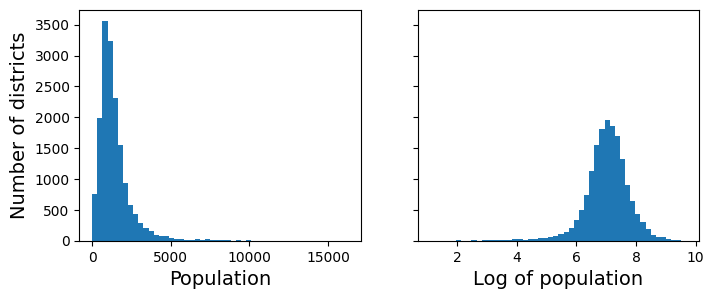

In [76]:
# extra code – this cell generates Figure 2–17
fig, axs = plt.subplots(1, 2, figsize=(8, 3), sharey=True)
axs[0].hist(housing["population"], bins=50)
axs[1].hist(np.log(housing["population"]), bins=50)
axs[0].set_xlabel("Population")
axs[1].set_xlabel("Log of population")
axs[0].set_ylabel("Number of districts")

plt.show()

What if we replace each value with its percentile?

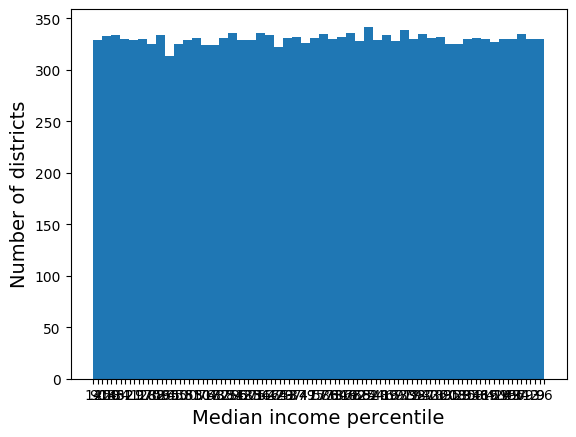

In [77]:
# extra code – just shows that we get a uniform distribution
percentiles = [np.percentile(housing["median_income"], p) for p in range(1, 100)]
flattened_median_income = housing["median_income"].cut(
    percentiles,
    labels=[str(i) for i in range(1, 100 + 1)],
)
plt.hist(flattened_median_income.cast(pl.String), bins=50)
plt.xlabel("Median income percentile")
plt.ylabel("Number of districts")
plt.show()
# Note: incomes below the 1st percentile are labeled 1, and incomes above the
# 99th percentile are labeled 100. This is why the distribution below ranges
# from 1 to 100 (not 0 to 100).

In [78]:
from sklearn.metrics.pairwise import rbf_kernel

age_simil_35 = rbf_kernel(housing[["housing_median_age"]], [[35]], gamma=0.1)

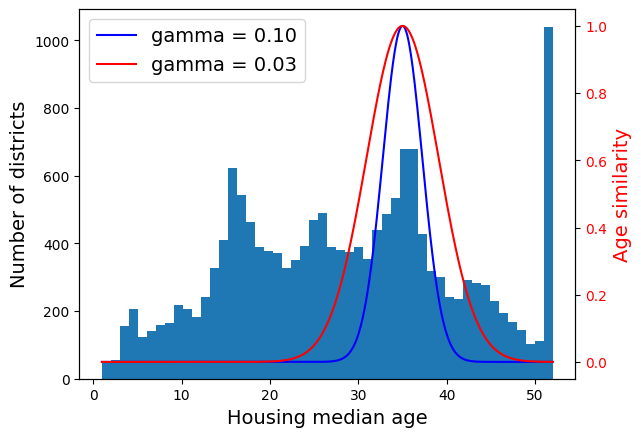

In [79]:
# extra code – this cell generates Figure 2–18

ages = np.linspace(
    housing["housing_median_age"].min(), housing["housing_median_age"].max(), 500
).reshape(-1, 1)
gamma1 = 0.1
gamma2 = 0.03
rbf1 = rbf_kernel(ages, [[35]], gamma=gamma1)
rbf2 = rbf_kernel(ages, [[35]], gamma=gamma2)

fig, ax1 = plt.subplots()

ax1.set_xlabel("Housing median age")
ax1.set_ylabel("Number of districts")
ax1.hist(housing["housing_median_age"], bins=50)

ax2 = ax1.twinx()  # create a twin axis that shares the same x-axis
color = "blue"
ax2.plot(ages, rbf1, color=color, label="gamma = 0.10")
color = "red"
ax2.plot(ages, rbf2, color=color, label="gamma = 0.03")
ax2.tick_params(axis="y", labelcolor=color)
ax2.set_ylabel("Age similarity", color=color)
ax2.legend(loc="upper left")

plt.show()

In [80]:
from sklearn.linear_model import LinearRegression

target_scaler = StandardScaler()
scaled_labels = target_scaler.fit_transform(housing_labels.to_frame())

model = LinearRegression()
model.fit(housing[["median_income"]], scaled_labels)
some_new_data = housing[["median_income"]].head(5)  # pretend this is new data

scaled_predictions = model.predict(some_new_data)
predictions = target_scaler.inverse_transform(scaled_predictions)

In [81]:
predictions

array([[131997.15275877],
       [299359.35844434],
       [146023.37185694],
       [138840.33653057],
       [192016.61557639]])

In [82]:
from sklearn.compose import TransformedTargetRegressor

model = TransformedTargetRegressor(LinearRegression(), transformer=StandardScaler())
model.fit(housing[["median_income"]], housing_labels)
predictions = model.predict(some_new_data)

In [83]:
predictions

array([131997.15275877, 299359.35844434, 146023.37185694, 138840.33653057,
       192016.61557639])

## Custom Transformers

To create simple transformers:

In [84]:
from sklearn.preprocessing import FunctionTransformer

log_transformer = FunctionTransformer(np.log, inverse_func=np.exp)
log_pop = log_transformer.transform(housing[["population"]])

In [85]:
rbf_transformer = FunctionTransformer(rbf_kernel, kw_args=dict(Y=[[35.0]], gamma=0.1))
age_simil_35 = rbf_transformer.transform(housing[["housing_median_age"]])

In [86]:
age_simil_35

array([[2.81118530e-13],
       [8.20849986e-02],
       [6.70320046e-01],
       ...,
       [9.55316054e-22],
       [6.70320046e-01],
       [3.03539138e-04]], shape=(16512, 1))

In [87]:
sf_coords = 37.7749, -122.41
sf_transformer = FunctionTransformer(rbf_kernel, kw_args=dict(Y=[sf_coords], gamma=0.1))
sf_simil = sf_transformer.transform(housing[["latitude", "longitude"]])

In [88]:
sf_simil

array([[0.999927  ],
       [0.05258419],
       [0.94864161],
       ...,
       [0.00388525],
       [0.05038518],
       [0.99868067]], shape=(16512, 1))

In [89]:
ratio_transformer = FunctionTransformer(lambda X: X[:, [0]] / X[:, [1]])
ratio_transformer.transform(np.array([[1.0, 2.0], [3.0, 4.0]]))

array([[0.5 ],
       [0.75]])

In [90]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.utils.validation import check_array, check_is_fitted


class StandardScalerClone(BaseEstimator, TransformerMixin):
    def __init__(self, with_mean=True):  # no *args or **kwargs!
        self.with_mean = with_mean

    def fit(self, X, y=None):  # y is required even though we don't use it
        X = check_array(X)  # checks that X is an array with finite float values
        self.mean_ = X.mean(axis=0)
        self.scale_ = X.std(axis=0)
        self.n_features_in_ = X.shape[1]  # every estimator stores this in fit()
        return self  # always return self!

    def transform(self, X):
        check_is_fitted(self)  # looks for learned attributes (with trailing _)
        X = check_array(X)
        assert self.n_features_in_ == X.shape[1]
        if self.with_mean:
            X = X - self.mean_
        return X / self.scale_

In [91]:
from sklearn.cluster import KMeans


class ClusterSimilarity(BaseEstimator, TransformerMixin):
    def __init__(self, n_clusters=10, gamma=1.0, random_state=None):
        self.n_clusters = n_clusters
        self.gamma = gamma
        self.random_state = random_state

    def fit(self, X, y=None, sample_weight=None):
        self.kmeans_ = KMeans(self.n_clusters, random_state=self.random_state)
        self.kmeans_.fit(X, sample_weight=sample_weight)
        return self  # always return self!

    def transform(self, X):
        return rbf_kernel(X, self.kmeans_.cluster_centers_, gamma=self.gamma)

    def get_feature_names_out(self, names=None):
        return [f"Cluster {i} similarity" for i in range(self.n_clusters)]

Let's cluster the districts based only on the latitude and longitude:

In [92]:
cluster_simil = ClusterSimilarity(n_clusters=10, gamma=1.0, random_state=42)
similarities = cluster_simil.fit_transform(housing[["latitude", "longitude"]])

In [93]:
similarities[:3].round(2)

array([[0.46, 0.  , 0.08, 0.  , 0.  , 0.  , 0.  , 0.98, 0.  , 0.  ],
       [0.  , 0.96, 0.  , 0.03, 0.04, 0.  , 0.  , 0.  , 0.11, 0.35],
       [0.34, 0.  , 0.45, 0.  , 0.  , 0.  , 0.01, 0.73, 0.  , 0.  ]])

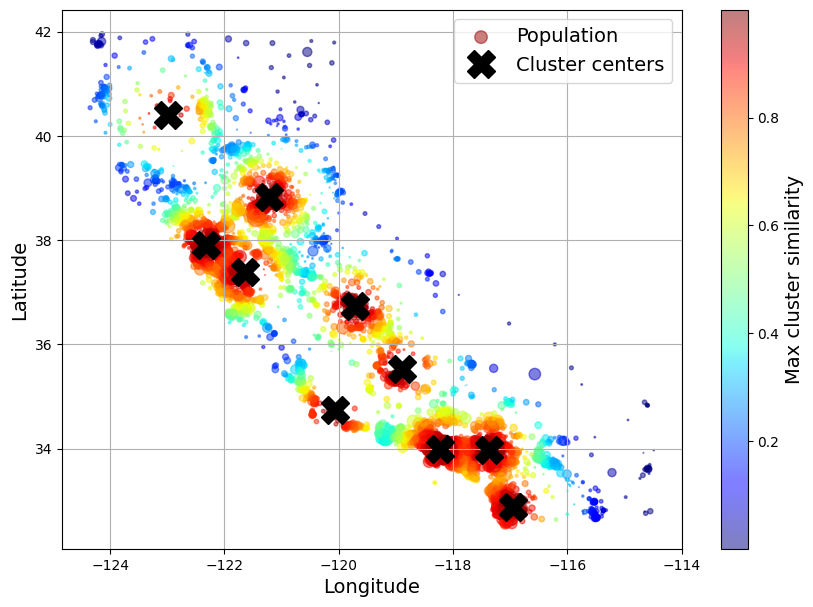

In [94]:
# extra code – this cell generates Figure 2–19

fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(
    housing["longitude"],
    housing["latitude"],
    s=housing["population"] / 100,
    c=similarities.max(axis=1),
    cmap="jet",
    alpha=0.5,
    label="Population",
)
plt.colorbar(scatter, label="Max cluster similarity")
ax.plot(
    cluster_simil.kmeans_.cluster_centers_[:, 1],
    cluster_simil.kmeans_.cluster_centers_[:, 0],
    linestyle="",
    color="black",
    marker="X",
    markersize=20,
    label="Cluster centers",
)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.legend(loc="upper right")
ax.grid(True)

plt.show()

## Transformation Pipelines

Now let's build a pipeline to preprocess the numerical attributes:

In [95]:
from sklearn.pipeline import Pipeline

num_pipeline = Pipeline(
    [
        ("impute", SimpleImputer(strategy="median")),
        ("standardize", StandardScaler()),
    ]
)

In [96]:
from sklearn.pipeline import make_pipeline

num_pipeline = make_pipeline(SimpleImputer(strategy="median"), StandardScaler())

In [97]:
from sklearn import set_config

set_config(display="diagram")

num_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('simpleimputer', ...), ('standardscaler', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite impu

In [98]:
housing_num_prepared = num_pipeline.fit_transform(housing_num)
housing_num_prepared[:2].round(2)

array([[-1.42,  1.01,  1.86,  0.31,  1.37,  0.14,  1.39, -0.94],
       [ 0.6 , -0.7 ,  0.91, -0.31, -0.44, -0.69, -0.37,  1.17]])

In [99]:
df_housing_num_prepared = pl.DataFrame(
    housing_num_prepared, schema=num_pipeline.get_feature_names_out().tolist()
)

In [100]:
df_housing_num_prepared.head(2)  # extra code

longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
f64,f64,f64,f64,f64,f64,f64,f64
-1.423037,1.013606,1.861119,0.311912,1.368167,0.13746,1.394812,-0.936491
0.596394,-0.702103,0.90763,-0.30862,-0.435925,-0.693771,-0.373485,1.171942


In [101]:
num_pipeline.steps

[('simpleimputer', SimpleImputer(strategy='median')),
 ('standardscaler', StandardScaler())]

In [102]:
num_pipeline[1]

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [103]:
num_pipeline[:-1]

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('simpleimputer', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feature has 

In [104]:
num_pipeline.named_steps["simpleimputer"]

,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feature has nomissing values at fit/train time, the feature won't appear onthe missing indicator even if there are missing values attransform/test time.",False
,"keep_empty_features keep_empty_features: bool, default=FalseIf True, features that consist exclusively of missing values when`fit` is called are returned in results when `transform` is called.The imputed value is always `0` except when `strategy=""constant""`in which case `fill_value` will be used instead... versionadded:: 1.2",False


In [105]:
num_pipeline.set_params(simpleimputer__strategy="median")

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('simpleimputer', ...), ('standardscaler', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite impu

In [106]:
from sklearn.compose import ColumnTransformer

num_attribs = [
    "longitude",
    "latitude",
    "housing_median_age",
    "total_rooms",
    "total_bedrooms",
    "population",
    "households",
    "median_income",
]
cat_attribs = ["ocean_proximity"]

cat_pipeline = make_pipeline(
    SimpleImputer(strategy="most_frequent"), OneHotEncoder(handle_unknown="ignore")
)

preprocessing = ColumnTransformer(
    [
        ("num", num_pipeline, num_attribs),
        ("cat", cat_pipeline, cat_attribs),
    ]
)

In [107]:
from sklearn.compose import make_column_transformer

num_attribs = housing.select(cs.numeric()).columns
cat_attribs = housing.select(cs.string()).columns

preprocessing = make_column_transformer(
    (num_pipeline, num_attribs),
    (cat_pipeline, cat_attribs),
)

In [108]:
housing_prepared = preprocessing.fit_transform(housing)

In [109]:
# extra code – shows that we can get a DataFrame out if we want
housing_prepared_fr = pl.DataFrame(
    housing_prepared, schema=preprocessing.get_feature_names_out().tolist()
)
housing_prepared_fr.head(2)

pipeline-1__longitude,pipeline-1__latitude,pipeline-1__housing_median_age,pipeline-1__total_rooms,pipeline-1__total_bedrooms,pipeline-1__population,pipeline-1__households,pipeline-1__median_income,pipeline-2__ocean_proximity_<1H OCEAN,pipeline-2__ocean_proximity_INLAND,pipeline-2__ocean_proximity_ISLAND,pipeline-2__ocean_proximity_NEAR BAY,pipeline-2__ocean_proximity_NEAR OCEAN
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
-1.423037,1.013606,1.861119,0.311912,1.368167,0.13746,1.394812,-0.936491,0.0,0.0,0.0,1.0,0.0
0.596394,-0.702103,0.90763,-0.30862,-0.435925,-0.693771,-0.373485,1.171942,1.0,0.0,0.0,0.0,0.0


In [110]:
def column_ratio(X):
    return X[:, [0]] / X[:, [1]]


def ratio_name(function_transformer, feature_names_in):
    return ["ratio"]  # feature names out


def ratio_pipeline():
    return make_pipeline(
        SimpleImputer(strategy="median"),
        FunctionTransformer(column_ratio, feature_names_out=ratio_name),
        StandardScaler(),
    )


log_pipeline = make_pipeline(
    SimpleImputer(strategy="median"),
    FunctionTransformer(np.log, feature_names_out="one-to-one"),
    StandardScaler(),
)

cluster_simil = ClusterSimilarity(n_clusters=10, gamma=1.0, random_state=42)

default_num_pipeline = make_pipeline(SimpleImputer(strategy="median"), StandardScaler())

preprocessing = ColumnTransformer(
    [
        ("bedrooms", ratio_pipeline(), ["total_bedrooms", "total_rooms"]),
        ("rooms_per_house", ratio_pipeline(), ["total_rooms", "households"]),
        ("people_per_house", ratio_pipeline(), ["population", "households"]),
        (
            "log",
            log_pipeline,
            [
                "total_bedrooms",
                "total_rooms",
                "population",
                "households",
                "median_income",
            ],
        ),
        ("geo", cluster_simil, ["latitude", "longitude"]),
        ("cat", cat_pipeline, housing.select(cs.string()).columns),
    ],
    remainder=default_num_pipeline,
)  # one column remaining: housing_median_age

In [111]:
housing_prepared = preprocessing.fit_transform(housing)
housing_prepared.shape

(16512, 24)

In [112]:
preprocessing.get_feature_names_out()

array(['bedrooms__ratio', 'rooms_per_house__ratio',
       'people_per_house__ratio', 'log__total_bedrooms',
       'log__total_rooms', 'log__population', 'log__households',
       'log__median_income', 'geo__Cluster 0 similarity',
       'geo__Cluster 1 similarity', 'geo__Cluster 2 similarity',
       'geo__Cluster 3 similarity', 'geo__Cluster 4 similarity',
       'geo__Cluster 5 similarity', 'geo__Cluster 6 similarity',
       'geo__Cluster 7 similarity', 'geo__Cluster 8 similarity',
       'geo__Cluster 9 similarity', 'cat__ocean_proximity_<1H OCEAN',
       'cat__ocean_proximity_INLAND', 'cat__ocean_proximity_ISLAND',
       'cat__ocean_proximity_NEAR BAY', 'cat__ocean_proximity_NEAR OCEAN',
       'remainder__housing_median_age'], dtype=object)

In [113]:
housing_prepared_fr = pl.DataFrame(
    housing_prepared, schema=preprocessing.get_feature_names_out().tolist()
)

housing_prepared_fr.head()

bedrooms__ratio,rooms_per_house__ratio,people_per_house__ratio,log__total_bedrooms,log__total_rooms,log__population,log__households,log__median_income,geo__Cluster 0 similarity,geo__Cluster 1 similarity,geo__Cluster 2 similarity,geo__Cluster 3 similarity,geo__Cluster 4 similarity,geo__Cluster 5 similarity,geo__Cluster 6 similarity,geo__Cluster 7 similarity,geo__Cluster 8 similarity,geo__Cluster 9 similarity,cat__ocean_proximity_<1H OCEAN,cat__ocean_proximity_INLAND,cat__ocean_proximity_ISLAND,cat__ocean_proximity_NEAR BAY,cat__ocean_proximity_NEAR OCEAN,remainder__housing_median_age
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
1.846624,-0.866027,-0.330204,1.324114,0.637892,0.456906,1.310369,-1.071522,0.458183,1.2418e-14,0.081412,3.4349e-24,3.3293e-7,0.00021,0.000849,0.977032,2.3822e-8,3.8191e-18,0.0,0.0,0.0,1.0,0.0,1.861119
-0.508121,0.02455,-0.253616,-0.252671,-0.063576,-0.711654,-0.14203,1.194712,6.5115e-10,0.95796,8.6495e-14,0.02713,0.03992,0.000208,5.6140e-27,1.2610e-13,0.110349,0.354761,1.0,0.0,0.0,0.0,0.0,0.90763
-0.202155,-0.041193,-0.051041,-0.925266,-0.859927,-0.941997,-0.91303,-0.756981,0.343251,4.2611e-15,0.44831,1.0411e-24,5.0847e-8,0.000411,0.005641,0.730326,2.5082e-8,2.6697e-18,0.0,1.0,0.0,0.0,0.0,0.351428
-0.149006,-0.034858,-0.141475,0.952773,0.943475,0.6707,0.925373,-0.912253,2.2448e-15,0.270482,2.8130e-19,0.464951,0.000058,1.5956e-7,5.9133e-35,5.2013e-20,0.001713,0.88746,0.0,1.0,0.0,0.0,0.0,-0.919891
0.963208,-0.666554,-0.306148,1.437622,1.00359,0.719093,1.481464,0.034537,1.0902e-11,0.942221,6.0167e-16,0.109262,0.009773,0.000014,5.4218e-30,1.0480e-15,0.025688,0.527951,0.0,0.0,0.0,0.0,1.0,0.5898


# Select and Train a Model

## Training and Evaluating on the Training Set

In [114]:
from sklearn.linear_model import LinearRegression

lin_reg = make_pipeline(preprocessing, LinearRegression())
lin_reg.fit(housing, housing_labels)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('linearregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('bedrooms', ...), ('rooms_per_house', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",Pipeline(step...ardScaler())])
,"sparse_threshold sparse_threshold: fl

Let's try the full preprocessing pipeline on a few training instances:

In [115]:
housing_predictions = lin_reg.predict(housing)
housing_predictions[:5].round(-2)  # -2 = rounded to the nearest hundred

array([246000., 372700., 135700.,  91400., 330900.])

Compare against the actual values:

In [116]:
housing_labels.head(5)

median_house_value
f64
458300.0
483800.0
101700.0
96100.0
361800.0


In [117]:
# extra code – computes the error ratios discussed in the book
error_ratios = housing_predictions[:5].round(-2) / housing_labels.head(5) - 1
print(", ".join([f"{100 * ratio:.1f}%" for ratio in error_ratios]))

-46.3%, -23.0%, 33.4%, -4.9%, -8.5%


In [118]:
from sklearn.metrics import root_mean_squared_error

lin_rmse = root_mean_squared_error(housing_labels, housing_predictions)
lin_rmse

68972.88910758478

In [119]:
from sklearn.tree import DecisionTreeRegressor

tree_reg = make_pipeline(preprocessing, DecisionTreeRegressor(random_state=42))
tree_reg.fit(housing, housing_labels)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('decisiontreeregressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('bedrooms', ...), ('rooms_per_house', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",Pipeline(step...ardScaler())])
,"sparse_threshold sparse_threshol

In [120]:
housing_predictions = tree_reg.predict(housing)
tree_rmse = root_mean_squared_error(housing_labels, housing_predictions)
tree_rmse

0.0

## Better Evaluation Using Cross-Validation

In [121]:
from sklearn.model_selection import cross_val_score

tree_rmses = -cross_val_score(
    tree_reg, housing, housing_labels, scoring="neg_root_mean_squared_error", cv=10
)

In [122]:
pl.Series("tree_rmses", tree_rmses).describe()

statistic,value
str,f64
"""count""",10.0
"""null_count""",0.0
"""mean""",67013.360949
"""std""",1460.19857
"""min""",64289.376198
"""25%""",66734.74035
"""50%""",67183.4997
"""75%""",68243.502386
"""max""",68659.29429


In [123]:
# extra code – computes the error stats for the linear model
lin_rmses = -cross_val_score(
    lin_reg, housing, housing_labels, scoring="neg_root_mean_squared_error", cv=10
)
pl.Series("lin_rmses", lin_rmses).describe()

statistic,value
str,f64
"""count""",10.0
"""null_count""",0.0
"""mean""",70003.404818
"""std""",4182.188328
"""min""",65504.765753
"""25%""",68090.538675
"""50%""",69063.096887
"""75%""",70507.515789
"""max""",81037.863741


**Warning:** the following cell may take a few minutes to run:

In [124]:
from sklearn.ensemble import RandomForestRegressor

forest_reg = make_pipeline(preprocessing, RandomForestRegressor(random_state=42))
forest_rmses = -cross_val_score(
    forest_reg, housing, housing_labels, scoring="neg_root_mean_squared_error", cv=10
)

In [125]:
pl.Series("forest_rmses", forest_rmses).describe()

statistic,value
str,f64
"""count""",10.0
"""null_count""",0.0
"""mean""",47124.604437
"""std""",1069.311372
"""min""",45292.329302
"""25%""",46691.772429
"""50%""",47191.649883
"""75%""",47623.633546
"""max""",49354.705514


Let's compare this RMSE measured using cross-validation (the "validation error") with the RMSE measured on the training set (the "training error"):

In [126]:
forest_reg.fit(housing, housing_labels)
housing_predictions = forest_reg.predict(housing)
forest_rmse = root_mean_squared_error(housing_labels, housing_predictions)
forest_rmse

17519.685029292894

The training error is much lower than the validation error, which usually means that the model has overfit the training set. Another possible explanation may be that there's a mismatch between the training data and the validation data, but it's not the case here, since both came from the same dataset that we shuffled and split in two parts.

# Fine-Tune Your Model

## Grid Search

**Warning:** the following cell may take a few minutes to run:

In [127]:
from sklearn.model_selection import GridSearchCV

full_pipeline = Pipeline(
    [
        ("preprocessing", preprocessing),
        ("random_forest", RandomForestRegressor(random_state=42)),
    ]
)
param_grid = [
    {
        "preprocessing__geo__n_clusters": [5, 8, 10],
        "random_forest__max_features": [4, 6, 8],
    },
    {
        "preprocessing__geo__n_clusters": [10, 15],
        "random_forest__max_features": [6, 8, 10],
    },
]
grid_search = GridSearchCV(
    full_pipeline, param_grid, cv=3, scoring="neg_root_mean_squared_error"
)
grid_search.fit(housing, housing_labels)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'preprocessing__geo__n_clusters': [5, 8, ...], 'random_forest__max_features': [4, 6, ...]}, {'preprocessing__geo__n_clusters': [10, 15], 'random_forest__max_features': [6, 8, ...]}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity

You can get the full list of hyperparameters available for tuning by looking at `full_pipeline.get_params().keys()`:

In [128]:
# extra code – shows part of the output of get_params().keys()
print(str(full_pipeline.get_params().keys())[:1000] + "...")

dict_keys(['memory', 'steps', 'transform_input', 'verbose', 'preprocessing', 'random_forest', 'preprocessing__force_int_remainder_cols', 'preprocessing__n_jobs', 'preprocessing__remainder__memory', 'preprocessing__remainder__steps', 'preprocessing__remainder__transform_input', 'preprocessing__remainder__verbose', 'preprocessing__remainder__simpleimputer', 'preprocessing__remainder__standardscaler', 'preprocessing__remainder__simpleimputer__add_indicator', 'preprocessing__remainder__simpleimputer__copy', 'preprocessing__remainder__simpleimputer__fill_value', 'preprocessing__remainder__simpleimputer__keep_empty_features', 'preprocessing__remainder__simpleimputer__missing_values', 'preprocessing__remainder__simpleimputer__strategy', 'preprocessing__remainder__standardscaler__copy', 'preprocessing__remainder__standardscaler__with_mean', 'preprocessing__remainder__standardscaler__with_std', 'preprocessing__remainder', 'preprocessing__sparse_threshold', 'preprocessing__transformer_weights', 

The best hyperparameter combination found:

In [129]:
grid_search.best_params_

{'preprocessing__geo__n_clusters': 15, 'random_forest__max_features': 6}

In [130]:
grid_search.best_estimator_

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('random_forest', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('bedrooms', ...), ('rooms_per_house', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",Pipeline(step...ardScaler())])
,"sparse_threshold sparse_threshold: float, de

Let's look at the score of each hyperparameter combination tested during the grid search:

In [131]:
cv_res = pl.DataFrame(grid_search.cv_results_)
cv_res = cv_res.sort("mean_test_score", descending=True)

# extra code – these few lines of code just make the DataFrame look nicer
cv_res = cv_res.select(
    [
        "param_preprocessing__geo__n_clusters",
        "param_random_forest__max_features",
        "split0_test_score",
        "split1_test_score",
        "split2_test_score",
        "mean_test_score",
    ]
)
cv_res = cv_res.rename(
    {
        "param_preprocessing__geo__n_clusters": "n_clusters",
        "param_random_forest__max_features": "max_features",
        "split0_test_score": "split0",
        "split1_test_score": "split1",
        "split2_test_score": "split2",
        "mean_test_score": "mean_test_rmse",
    }
)
score_cols = ["split0", "split1", "split2", "mean_test_rmse"]
cv_res = cv_res.with_columns(
    [(-pl.col(c).round(0).cast(pl.Int64)).alias(c) for c in score_cols]
)

cv_res.head()

n_clusters,max_features,split0,split1,split2,mean_test_rmse
i64,i64,i64,i64,i64,i64
15,6,43521,43958,44760,44080
15,8,44027,44180,45007,44405
15,10,44403,44619,45424,44815
10,6,44251,44825,45611,44896
10,6,44251,44825,45611,44896


## Randomized Search

In [132]:
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingRandomSearchCV

Try 30 (`n_iter` × `cv`) random combinations of hyperparameters:

**Warning:** the following cell may take a few minutes to run:

In [133]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

param_distribs = {
    "preprocessing__geo__n_clusters": randint(low=3, high=50),
    "random_forest__max_features": randint(low=2, high=20),
}

rnd_search = RandomizedSearchCV(
    full_pipeline,
    param_distributions=param_distribs,
    n_iter=10,
    cv=3,
    scoring="neg_root_mean_squared_error",
    random_state=42,
)

rnd_search.fit(housing, housing_labels)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'preprocessing__geo__n_clusters': <scipy.stats....x7f007832fc20>, 'random_forest__max_features': <scipy.stats....x7f00783e5700>}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies th

In [134]:
# extra code – displays the random search results
cv_res = pl.DataFrame(rnd_search.cv_results_)
cv_res = cv_res.sort("mean_test_score", descending=True)
cv_res = cv_res.select(
    [
        "param_preprocessing__geo__n_clusters",
        "param_random_forest__max_features",
        "split0_test_score",
        "split1_test_score",
        "split2_test_score",
        "mean_test_score",
    ]
)
cv_res = cv_res.rename(
    {
        "param_preprocessing__geo__n_clusters": "n_clusters",
        "param_random_forest__max_features": "max_features",
        "split0_test_score": "split0",
        "split1_test_score": "split1",
        "split2_test_score": "split2",
        "mean_test_score": "mean_test_rmse",
    }
)
score_cols = ["split0", "split1", "split2", "mean_test_rmse"]
cv_res = cv_res.with_columns(
    [(-pl.col(c).round(0).cast(pl.Int64)).alias(c) for c in score_cols]
)
cv_res.head()

n_clusters,max_features,split0,split1,split2,mean_test_rmse
i64,i64,i64,i64,i64,i64
45,9,41204,42108,42998,42103
32,7,41991,42557,43431,42660
42,4,42031,42968,43617,42872
41,16,42580,42869,43604,43018
23,8,42421,42841,44232,43165


**Bonus section: how to choose the sampling distribution for a hyperparameter**

* `scipy.stats.randint(a, b+1)`: for hyperparameters with _discrete_ values that range from a to b, and all values in that range seem equally likely.
* `scipy.stats.uniform(a, b)`: this is very similar, but for _continuous_ hyperparameters.
* `scipy.stats.geom(1 / scale)`: for discrete values, when you want to sample roughly in a given scale. E.g., with scale=1000 most samples will be in this ballpark, but ~10% of all samples will be <100 and ~10% will be >2300.
* `scipy.stats.expon(scale)`: this is the continuous equivalent of `geom`. Just set `scale` to the most likely value.
* `scipy.stats.loguniform(a, b)`: when you have almost no idea what the optimal hyperparameter value's scale is. If you set a=0.01 and b=100, then you're just as likely to sample a value between 0.01 and 0.1 as a value between 10 and 100.


Here are plots of the probability mass functions (for discrete variables), and probability density functions (for continuous variables) for `randint()`, `uniform()`, `geom()` and `expon()`:

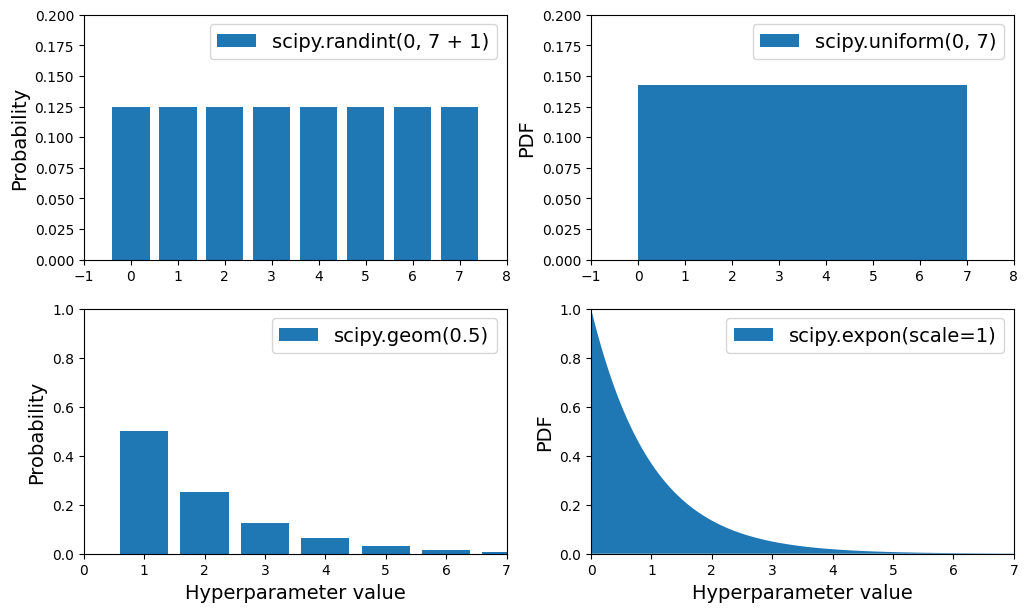

In [135]:
# extra code – plots a few distributions you can use in randomized search

from scipy.stats import randint, uniform, geom, expon

xs1 = np.arange(0, 7 + 1)
randint_distrib = randint(0, 7 + 1).pmf(xs1)

xs2 = np.linspace(0, 7, 500)
uniform_distrib = uniform(0, 7).pdf(xs2)

xs3 = np.arange(0, 7 + 1)
geom_distrib = geom(0.5).pmf(xs3)

xs4 = np.linspace(0, 7, 500)
expon_distrib = expon(scale=1).pdf(xs4)

plt.figure(figsize=(12, 7))

plt.subplot(2, 2, 1)
plt.bar(xs1, randint_distrib, label="scipy.randint(0, 7 + 1)")
plt.ylabel("Probability")
plt.legend()
plt.axis([-1, 8, 0, 0.2])

plt.subplot(2, 2, 2)
plt.fill_between(xs2, uniform_distrib, label="scipy.uniform(0, 7)")
plt.ylabel("PDF")
plt.legend()
plt.axis([-1, 8, 0, 0.2])

plt.subplot(2, 2, 3)
plt.bar(xs3, geom_distrib, label="scipy.geom(0.5)")
plt.xlabel("Hyperparameter value")
plt.ylabel("Probability")
plt.legend()
plt.axis([0, 7, 0, 1])

plt.subplot(2, 2, 4)
plt.fill_between(xs4, expon_distrib, label="scipy.expon(scale=1)")
plt.xlabel("Hyperparameter value")
plt.ylabel("PDF")
plt.legend()
plt.axis([0, 7, 0, 1])

plt.show()

Here are the PDF for `expon()` and `loguniform()` (left column), as well as the PDF of log(X) (right column). The right column shows the distribution of hyperparameter _scales_. You can see that `expon()` favors hyperparameters with roughly the desired scale, with a longer tail towards the smaller scales. But `loguniform()` does not favor any scale, they are all equally likely:

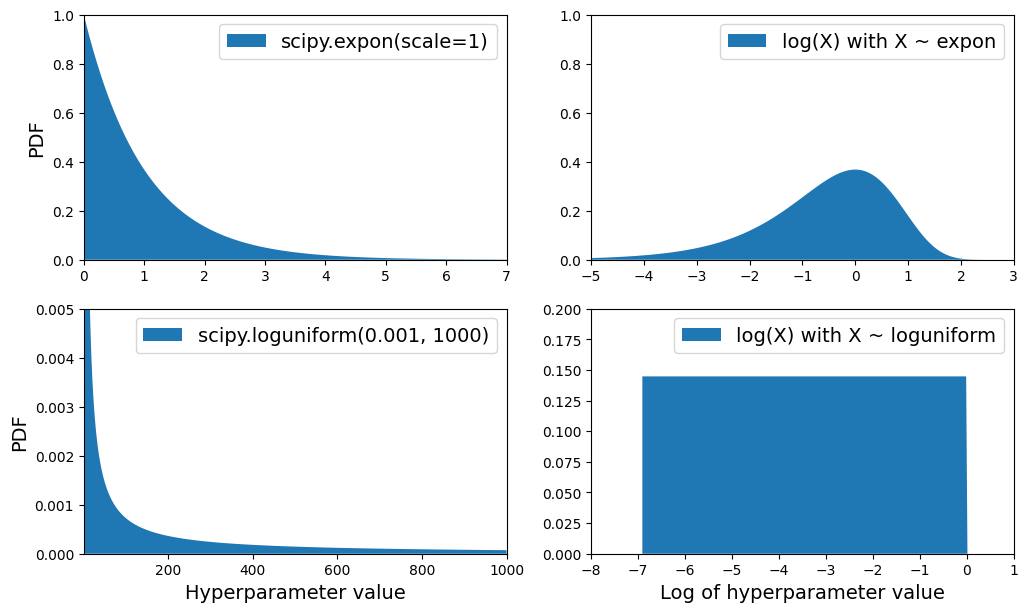

In [136]:
# extra code – shows the difference between expon and loguniform

from scipy.stats import loguniform

xs1 = np.linspace(0, 7, 500)
expon_distrib = expon(scale=1).pdf(xs1)

log_xs2 = np.linspace(-5, 3, 500)
log_expon_distrib = np.exp(log_xs2 - np.exp(log_xs2))

xs3 = np.linspace(0.001, 1000, 500)
loguniform_distrib = loguniform(0.001, 1000).pdf(xs3)

log_xs4 = np.linspace(np.log(0.001), np.log(1000), 500)
log_loguniform_distrib = uniform(np.log(0.001), np.log(1000)).pdf(log_xs4)

plt.figure(figsize=(12, 7))

plt.subplot(2, 2, 1)
plt.fill_between(xs1, expon_distrib, label="scipy.expon(scale=1)")
plt.ylabel("PDF")
plt.legend()
plt.axis([0, 7, 0, 1])

plt.subplot(2, 2, 2)
plt.fill_between(log_xs2, log_expon_distrib, label="log(X) with X ~ expon")
plt.legend()
plt.axis([-5, 3, 0, 1])

plt.subplot(2, 2, 3)
plt.fill_between(xs3, loguniform_distrib, label="scipy.loguniform(0.001, 1000)")
plt.xlabel("Hyperparameter value")
plt.ylabel("PDF")
plt.legend()
plt.axis([0.001, 1000, 0, 0.005])

plt.subplot(2, 2, 4)
plt.fill_between(log_xs4, log_loguniform_distrib, label="log(X) with X ~ loguniform")
plt.xlabel("Log of hyperparameter value")
plt.legend()
plt.axis([-8, 1, 0, 0.2])

plt.show()

## Analyze the Best Models and Their Errors

In [137]:
final_model = rnd_search.best_estimator_  # includes preprocessing
feature_importances = final_model["random_forest"].feature_importances_
feature_importances.round(2)

array([0.06, 0.06, 0.05, 0.01, 0.01, 0.01, 0.01, 0.19, 0.01, 0.02, 0.01,
       0.02, 0.01, 0.  , 0.01, 0.01, 0.01, 0.02, 0.01, 0.  , 0.01, 0.01,
       0.01, 0.  , 0.01, 0.  , 0.02, 0.01, 0.01, 0.  , 0.01, 0.01, 0.01,
       0.02, 0.02, 0.01, 0.01, 0.01, 0.04, 0.01, 0.02, 0.01, 0.01, 0.01,
       0.02, 0.01, 0.  , 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.  , 0.08,
       0.  , 0.  , 0.  , 0.01])

In [138]:
# sorted(
#     zip(feature_importances, final_model["preprocessing"].get_feature_names_out()),
#     reverse=True,
# )

# Create DataFrame for easy viewing/manipulation
feature_importance_df = pl.DataFrame(
    {
        "feature": final_model["preprocessing"].get_feature_names_out().tolist(),
        "importance": feature_importances,
    }
).sort("importance", descending=True)


# Print all rows

with pl.Config(tbl_rows=-1, tbl_cols=-1, tbl_width_chars=-1):
    print(feature_importance_df)


# # Or convert to list of tuples if needed
# sorted_features = list(
#     zip(
#         feature_importance_df["importance"].to_list(),
#         feature_importance_df["feature"].to_list(),
#     )
# )

shape: (59, 2)
┌─────────────────────────────────┬────────────┐
│ feature                         ┆ importance │
│ ---                             ┆ ---        │
│ str                             ┆ f64        │
╞═════════════════════════════════╪════════════╡
│ log__median_income              ┆ 0.188366   │
│ cat__ocean_proximity_INLAND     ┆ 0.07796    │
│ bedrooms__ratio                 ┆ 0.061104   │
│ rooms_per_house__ratio          ┆ 0.057722   │
│ people_per_house__ratio         ┆ 0.045693   │
│ geo__Cluster 30 similarity      ┆ 0.041977   │
│ geo__Cluster 9 similarity       ┆ 0.024893   │
│ geo__Cluster 36 similarity      ┆ 0.023491   │
│ geo__Cluster 18 similarity      ┆ 0.021385   │
│ geo__Cluster 3 similarity       ┆ 0.019232   │
│ geo__Cluster 32 similarity      ┆ 0.019114   │
│ geo__Cluster 25 similarity      ┆ 0.017401   │
│ geo__Cluster 1 similarity       ┆ 0.016282   │
│ geo__Cluster 26 similarity      ┆ 0.015975   │
│ geo__Cluster 7 similarity       ┆ 0.014014   │
│ geo

## Evaluate Your System on the Test Set

In [139]:
X_test = strat_test_set.drop("median_house_value")
y_test = strat_test_set["median_house_value"]

final_predictions = final_model.predict(X_test)

final_rmse = root_mean_squared_error(y_test, final_predictions)
print(final_rmse)

41422.168800999665


We can compute a 95% confidence interval for the test RMSE using SciPy's `bootstrap()` function:

In [140]:
from scipy.stats import bootstrap


def rmse(squared_errors):
    return np.sqrt(np.mean(squared_errors))


confidence = 0.95
squared_errors = (final_predictions - y_test) ** 2
boot_result = bootstrap(
    [squared_errors], rmse, confidence_level=confidence, random_state=42
)
rmse_lower, rmse_upper = boot_result.confidence_interval

In [141]:
print(f"95% CI for RMSE: ({rmse_lower:.4f}, {rmse_upper:.4f})")

95% CI for RMSE: (39487.5429, 43654.0546)


## Model persistence using joblib

Save the final model:

In [142]:
import joblib

joblib.dump(final_model, "my_california_housing_model.pkl")

['my_california_housing_model.pkl']

Now you can deploy this model to production. For example, the following code could be a script that would run in production:

In [143]:
import joblib

# extra code – excluded for conciseness
from sklearn.cluster import KMeans
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics.pairwise import rbf_kernel


def column_ratio(X):
    return X[:, [0]] / X[:, [1]]


# class ClusterSimilarity(BaseEstimator, TransformerMixin):
#    [...]

final_model_reloaded = joblib.load("my_california_housing_model.pkl")

new_data = housing.head(5)  # pretend these are new districts
predictions = final_model_reloaded.predict(new_data)

In [144]:
predictions

array([440208.11, 457822.08, 106671.  , 100105.  , 330637.02])

You could use pickle instead, but joblib is more efficient.

# Exercise solutions

## 1.

Exercise: _Try a Support Vector Machine regressor (`sklearn.svm.SVR`) with various hyperparameters, such as `kernel="linear"` (with various values for the `C` hyperparameter) or `kernel="rbf"` (with various values for the `C` and `gamma` hyperparameters). Note that SVMs don't scale well to large datasets, so you should probably train your model on just the first 5,000 instances of the training set and use only 3-fold cross-validation, or else it will take hours. Don't worry about what the hyperparameters mean for now (see the SVM notebook if you're interested). How does the best `SVR` predictor perform?_

In [145]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVR

param_grid = [
    {
        "svr__kernel": ["linear"],
        "svr__C": [10.0, 30.0, 100.0, 300.0, 1000.0, 3000.0, 10000.0, 30000.0],
    },
    {
        "svr__kernel": ["rbf"],
        "svr__C": [1.0, 3.0, 10.0, 30.0, 100.0, 300.0, 1000.0],
        "svr__gamma": [0.01, 0.03, 0.1, 0.3, 1.0, 3.0],
    },
]

svr_pipeline = Pipeline([("preprocessing", preprocessing), ("svr", SVR())])
grid_search = GridSearchCV(
    svr_pipeline, param_grid, cv=3, scoring="neg_root_mean_squared_error"
)
grid_search.fit(housing.head(5000), housing_labels.head(5000))

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...svr', SVR())])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'svr__C': [10.0, 30.0, ...], 'svr__kernel': ['linear']}, {'svr__C': [1.0, 3.0, ...], 'svr__gamma': [0.01, 0.03, ...], 'svr__kernel': ['rbf']}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 

The best model achieves the following score (evaluated using 3-fold cross validation):

In [146]:
svr_grid_search_rmse = -grid_search.best_score_
svr_grid_search_rmse

np.float64(70059.92771306196)

That's much worse than the `RandomForestRegressor` (but to be fair, we trained the model on much less data). Let's check the best hyperparameters found:

In [147]:
grid_search.best_params_

{'svr__C': 10000.0, 'svr__kernel': 'linear'}

The linear kernel seems better than the RBF kernel. Notice that the value of `C` is the maximum tested value. When this happens you definitely want to launch the grid search again with higher values for `C` (removing the smallest values), because it is likely that higher values of `C` will be better.

## 2.

Exercise: _Try replacing the `GridSearchCV` with a `RandomizedSearchCV`._

**Warning:** the following cell will take several minutes to run. You can specify `verbose=2` when creating the `RandomizedSearchCV` if you want to see the training details.

In [148]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import expon, loguniform

# see https://docs.scipy.org/doc/scipy/reference/stats.html
# for `expon()` and `loguniform()` documentation and more probability distribution functions.

# Note: gamma is ignored when kernel is "linear"
param_distribs = {
    "svr__kernel": ["linear", "rbf"],
    "svr__C": loguniform(20, 200_000),
    "svr__gamma": expon(scale=1.0),
}

rnd_search = RandomizedSearchCV(
    svr_pipeline,
    param_distributions=param_distribs,
    n_iter=50,
    cv=3,
    scoring="neg_root_mean_squared_error",
    random_state=42,
)
rnd_search.fit(housing.head(5000), housing_labels.head(5000))

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...svr', SVR())])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'svr__C': <scipy.stats....x7f00783e4b60>, 'svr__gamma': <scipy.stats....x7f003812f2c0>, 'svr__kernel': ['linear', 'rbf']}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that ca

The best model achieves the following score (evaluated using 3-fold cross validation):

In [149]:
svr_rnd_search_rmse = -rnd_search.best_score_
svr_rnd_search_rmse

np.float64(56152.05369563578)

Now that's really much better, but still far from the `RandomForestRegressor`'s performance. Let's check the best hyperparameters found:

In [150]:
rnd_search.best_params_

{'svr__C': np.float64(157055.10989448498),
 'svr__gamma': np.float64(0.26497040005002437),
 'svr__kernel': 'rbf'}

This time the search found a good set of hyperparameters for the RBF kernel. Randomized search tends to find better hyperparameters than grid search in the same amount of time.

Note that we used the `expon()` distribution for `gamma`, with a scale of 1, so `RandomSearch` mostly searched for values roughly of that scale: about 80% of the samples were between 0.1 and 2.3 (roughly 10% were smaller and 10% were larger):

In [151]:
s = expon(scale=1).rvs(100_000, random_state=42)  # get 100,000 samples
((s > 0.105) & (s < 2.29)).sum() / 100_000

np.float64(0.80066)

We used the `loguniform()` distribution for `C`, meaning we did not have a clue what the optimal scale of `C` was before running the random search. It explored the range from 20 to 200 just as much as the range from 2,000 to 20,000 or from 20,000 to 200,000.

## 3.

Exercise: _Try adding a `SelectFromModel` transformer in the preparation pipeline to select only the most important attributes._

Let's create a new pipeline that runs the previously defined preparation pipeline, and adds a `SelectFromModel` transformer based on a `RandomForestRegressor` before the final regressor:

In [152]:
from sklearn.feature_selection import SelectFromModel

selector_pipeline = Pipeline(
    [
        ("preprocessing", preprocessing),
        (
            "selector",
            SelectFromModel(RandomForestRegressor(random_state=42), threshold=0.005),
        ),  # min feature importance
        (
            "svr",
            SVR(
                C=rnd_search.best_params_["svr__C"],
                gamma=rnd_search.best_params_["svr__gamma"],
                kernel=rnd_search.best_params_["svr__kernel"],
            ),
        ),
    ]
)

In [153]:
selector_rmses = -cross_val_score(
    selector_pipeline,
    housing.head(5000),
    housing_labels.head(5000),
    scoring="neg_root_mean_squared_error",
    cv=3,
)
pl.Series("selector_rmses", selector_rmses).describe()

statistic,value
str,f64
"""count""",3.0
"""null_count""",0.0
"""mean""",56622.643482
"""std""",2272.666705
"""min""",54243.24229
"""25%""",56853.776697
"""50%""",56853.776697
"""75%""",58770.91146
"""max""",58770.91146


Oh well, feature selection does not seem to help. But maybe that's just because the threshold we used was not optimal. Perhaps try tuning it using random search or grid search?

## 4.

Exercise: _Try creating a custom transformer that trains a k-nearest neighbors regressor (`sklearn.neighbors.KNeighborsRegressor`) in its `fit()` method, and outputs the model's predictions in its `transform()` method. The KNN regressor should use only the latitude and longitude as input and predict the median income. Next, add this new transformer to the preprocessing pipeline. This will add a feature representing the smoothed median income over the nearby districts._

Rather than restrict ourselves to k-Nearest Neighbors regressors, let's create a transformer that accepts any regressor. For this, we can extend the `MetaEstimatorMixin` and have a required `estimator` argument in the constructor. The `fit()` method must work on a clone of this estimator, and it must also save <code>feature_names_in&#95;</code>. The `MetaEstimatorMixin` will ensure that `estimator` is listed as a required parameters, and it will update `get_params()` and `set_params()` to make the estimator's hyperparameters available for tuning. Lastly, we create a `get_feature_names_out()` method.

In [154]:
from sklearn.base import MetaEstimatorMixin, clone


class FeatureFromRegressor(BaseEstimator, TransformerMixin, MetaEstimatorMixin):
    def __init__(self, regressor, target_features):
        self.regressor = regressor
        self.target_features = target_features

    def fit(self, X, y=None):
        if hasattr(X, "columns"):
            self.feature_names_in_ = list(X.columns)
            X_df = X if isinstance(X, pl.DataFrame) else pl.DataFrame(X)
        else:
            X_df = pl.DataFrame(X)

        self.input_features_ = [
            c for c in X_df.columns if c not in self.target_features
        ]
        self.regressor_ = clone(self.regressor)
        self.regressor_.fit(
            X_df.select(self.input_features_), X_df.select(self.target_features)
        )
        return self

    def transform(self, X):
        columns = X.columns if hasattr(X, "columns") else None
        if isinstance(X, pl.DataFrame):
            X_df = X
        else:
            X_df = pl.DataFrame(X, schema=columns) if columns else pl.DataFrame(X)
        preds = self.regressor_.predict(X_df.select(self.input_features_))
        if preds.ndim == 1:
            preds = preds.reshape(-1, 1)
        extra_columns = [f"pred_{t}" for t in self.target_features]
        preds_df = pl.DataFrame(dict(zip(extra_columns, preds.T)))
        return pl.concat([X_df, preds_df], how="horizontal")

    def get_feature_names_out(self, input_features=None):
        extra_columns = [f"pred_{t}" for t in self.target_features]
        return self.feature_names_in_ + extra_columns

Good! Now let's test it:

In [155]:
from sklearn.neighbors import KNeighborsRegressor

knn_reg = KNeighborsRegressor(n_neighbors=3, weights="distance")
knn_transformer = FeatureFromRegressor(knn_reg, ["median_income"])
geo_features = housing[["latitude", "longitude", "median_income"]]
knn_transformer.fit_transform(geo_features, housing_labels)

latitude,longitude,median_income,pred_median_income
f64,f64,f64,f64
37.8,-122.42,2.0987,3.347233
34.14,-118.38,6.0876,6.8994
38.36,-121.98,2.433,2.9009
33.75,-117.11,2.2618,2.2618
33.77,-118.15,3.5292,3.475633
…,…,…,…
33.86,-118.4,4.7105,4.9391
36.32,-119.31,2.5733,3.30155
32.59,-117.06,4.0616,4.0616


And what does its output feature name look like?

In [156]:
knn_transformer.get_feature_names_out()

['latitude', 'longitude', 'median_income', 'pred_median_income']

Okay, now let's include this transformer in our preprocessing pipeline:

In [157]:
from sklearn.base import clone

transformers = [
    (name, clone(transformer), columns)
    for name, transformer, columns in preprocessing.transformers
]
geo_index = [name for name, _, _ in transformers].index("geo")
transformers[geo_index] = (
    "geo",
    knn_transformer,
    ["latitude", "longitude", "median_income"],
)
new_geo_preprocessing = ColumnTransformer(transformers)

In [158]:
new_geo_pipeline = Pipeline(
    [
        ("preprocessing", new_geo_preprocessing),
        (
            "svr",
            SVR(
                C=rnd_search.best_params_["svr__C"],
                gamma=rnd_search.best_params_["svr__gamma"],
                kernel=rnd_search.best_params_["svr__kernel"],
            ),
        ),
    ]
)

In [159]:
new_pipe_rmses = -cross_val_score(
    new_geo_pipeline,
    housing.head(5000),
    housing_labels.head(5000),
    scoring="neg_root_mean_squared_error",
    cv=3,
)
pl.Series("new_pipe_rmses", new_pipe_rmses).describe()

statistic,value
str,f64
"""count""",3.0
"""null_count""",0.0
"""mean""",68782.438065
"""std""",2458.334599
"""min""",66161.322618
"""25%""",69149.213845
"""50%""",69149.213845
"""75%""",71036.777733
"""max""",71036.777733


Yikes, that's terrible! Apparently the cluster similarity features were much better. But perhaps we should tune the `KNeighborsRegressor`'s hyperparameters? That's what the next exercise is about.

## 5.

Exercise: _Automatically explore some preparation options using `RandomSearchCV`._

In [160]:
param_distribs = {
    "preprocessing__geo__regressor__n_neighbors": range(1, 30),
    "preprocessing__geo__regressor__weights": ["distance", "uniform"],
    "svr__C": loguniform(20, 200_000),
    "svr__gamma": expon(scale=1.0),
}

new_geo_rnd_search = RandomizedSearchCV(
    new_geo_pipeline,
    param_distributions=param_distribs,
    n_iter=50,
    cv=3,
    scoring="neg_root_mean_squared_error",
    random_state=42,
)
new_geo_rnd_search.fit(housing.head(5000), housing_labels.head(5000))

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...005002437)))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'preprocessing__geo__regressor__n_neighbors': range(1, 30), 'preprocessing__geo__regressor__weights': ['distance', 'uniform'], 'svr__C': <scipy.stats....x7f0038e0c290>, 'svr__gamma': <scipy.stats....x7f0038e0c350>}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the sa

In [161]:
new_geo_rnd_search_rmse = -new_geo_rnd_search.best_score_
new_geo_rnd_search_rmse

np.float64(64573.262757363635)

Oh well... at least we tried! It looks like the cluster similarity features are definitely better than the KNN feature. But perhaps you could try having both? And maybe training on the full training set would help as well.

## 6.

Exercise: _Try to implement the `StandardScalerClone` class again from scratch, then add support for the `inverse_transform()` method: executing `scaler.inverse_transform(scaler.fit_transform(X))` should return an array very close to `X`. Then add support for feature names: set <code>feature_names_in&#95;</code> in the `fit()` method if the input is a DataFrame. This attribute should be a NumPy array of column names. Lastly, implement the `get_feature_names_out()` method: it should have one optional `input_features=None` argument. If passed, the method should check that its length matches <code>n_features_in&#95;</code>, and it should match <code>feature_names_in&#95;</code> if it is defined, then `input_features` should be returned. If `input_features` is `None`, then the method should return <code>feature_names_in&#95;</code> if it is defined or `np.array(["x0", "x1", ...])` with length <code>n_features_in&#95;</code> otherwise._

In [162]:
import numpy as np
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.utils.validation import check_is_fitted, validate_data


class StandardScalerClone(TransformerMixin, BaseEstimator):
    def __init__(self, with_mean=True):  # no *args or **kwargs!
        self.with_mean = with_mean

    def fit(self, X, y=None):
        X = validate_data(self, X, ensure_2d=True)
        self.n_features_in_ = X.shape[1]
        if self.with_mean:
            self.mean_ = np.mean(X, axis=0)
        self.scale_ = np.std(X, axis=0, ddof=0)
        self.scale_[self.scale_ == 0] = 1  # Avoid division by zero
        return self

    def transform(self, X):
        check_is_fitted(self)
        X = validate_data(self, X, ensure_2d=True, reset=False)
        if self.with_mean:
            X = X - self.mean_
        return X / self.scale_

    def inverse_transform(self, X):
        check_is_fitted(self)
        X = validate_data(self, X, ensure_2d=True, reset=False)
        return X * self.scale_ + self.mean_

    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            return getattr(
                self, "feature_names_in_", [f"x{i}" for i in range(self.n_features_in_)]
            )
        else:
            if len(input_features) != self.n_features_in_:
                raise ValueError("Invalid number of features")
            if hasattr(self, "feature_names_in_") and not np.all(
                self.feature_names_in_ == input_features
            ):
                raise ValueError("input_features ≠ feature_names_in_")
            return input_features

Let's test our custom transformer:

In [163]:
from sklearn.utils.estimator_checks import check_estimator

check_estimator(StandardScalerClone())

[{'estimator': StandardScalerClone(),
  'check_name': 'check_estimator_cloneable',
  'exception': None,
  'status': 'passed',
  'expected_to_fail': False,
  'expected_to_fail_reason': 'Check is not expected to fail'},
 {'estimator': StandardScalerClone(),
  'check_name': 'check_estimator_cloneable',
  'exception': None,
  'status': 'passed',
  'expected_to_fail': False,
  'expected_to_fail_reason': 'Check is not expected to fail'},
 {'estimator': StandardScalerClone(),
  'check_name': 'check_estimator_tags_renamed',
  'exception': None,
  'status': 'passed',
  'expected_to_fail': False,
  'expected_to_fail_reason': 'Check is not expected to fail'},
 {'estimator': StandardScalerClone(),
  'check_name': 'check_valid_tag_types',
  'exception': None,
  'status': 'passed',
  'expected_to_fail': False,
  'expected_to_fail_reason': 'Check is not expected to fail'},
 {'estimator': StandardScalerClone(),
  'check_name': 'check_estimator_repr',
  'exception': None,
  'status': 'passed',
  'expec

No errors, that's a great start, we respect the Scikit-Learn API.

Now let's ensure the transformation works as expected:

In [164]:
rng = np.random.default_rng(seed=42)
X = rng.random((1000, 3))

scaler = StandardScalerClone()
X_scaled = scaler.fit_transform(X)

assert np.allclose(X_scaled, (X - X.mean(axis=0)) / X.std(axis=0))

How about setting `with_mean=False`?

In [165]:
scaler = StandardScalerClone(with_mean=False)
X_scaled_uncentered = scaler.fit_transform(X)

assert np.allclose(X_scaled_uncentered, X / X.std(axis=0))

And does the inverse work?

In [166]:
scaler = StandardScalerClone()
X_back = scaler.inverse_transform(scaler.fit_transform(X))

assert np.allclose(X, X_back)

How about the feature names out?

In [167]:
assert np.all(scaler.get_feature_names_out() == ["x0", "x1", "x2"])
assert np.all(scaler.get_feature_names_out(["a", "b", "c"]) == ["a", "b", "c"])

And if we fit a DataFrame, are the feature in and out ok?

In [168]:
df = pl.DataFrame({"a": rng.random(100), "b": rng.random(100)})
scaler = StandardScalerClone()
X_scaled = scaler.fit_transform(df)

assert np.all(scaler.feature_names_in_ == ["a", "b"])
assert np.all(scaler.get_feature_names_out() == ["a", "b"])

All good! That's all for today! 😀

Congratulations! You already know quite a lot about Machine Learning. :)